<a href="https://colab.research.google.com/github/yiyandeng0304/CREMA-D/blob/master/TeamLab_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The graph highlighting models performance on different feature sets by Val and Test accuracy.

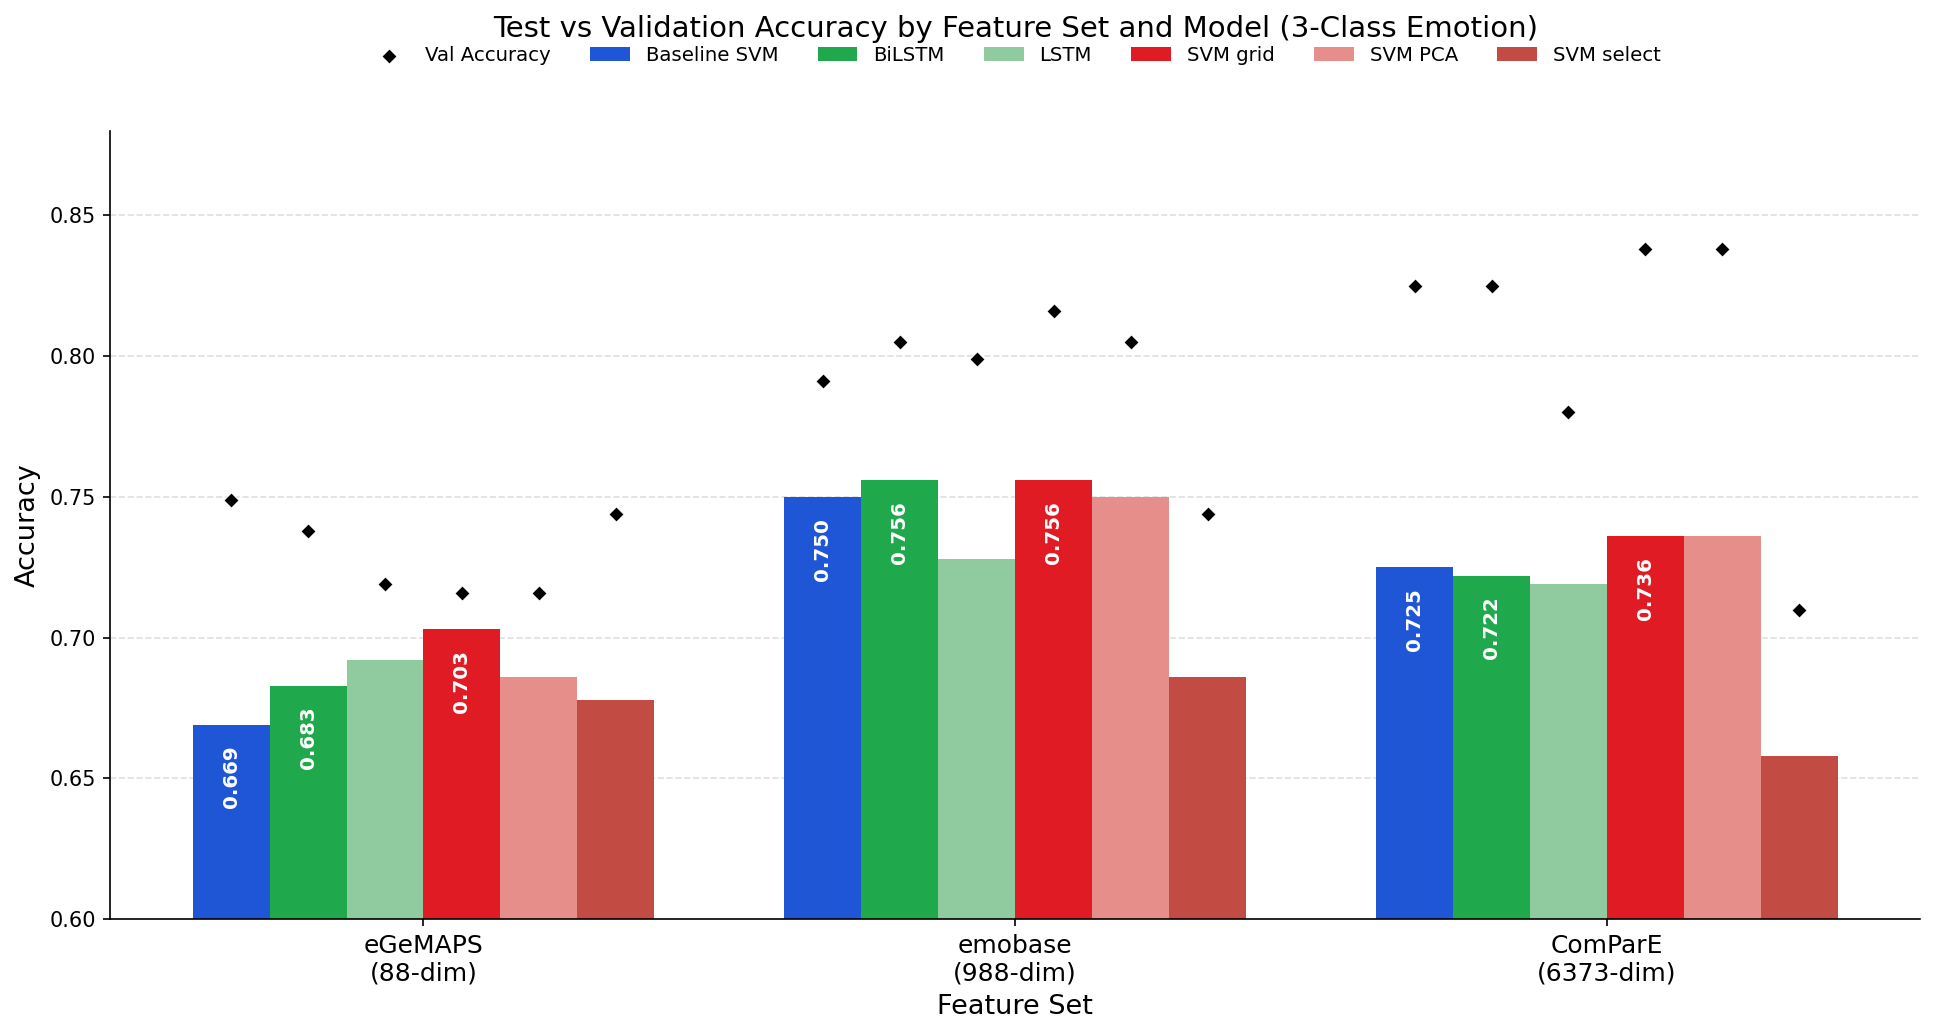

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

feature_sets = ["eGeMAPS\n(88-dim)", "emobase\n(988-dim)", "ComParE\n(6373-dim)"]

models = ["Baseline SVM", "BiLSTM", "LSTM", "SVM grid", "SVM PCA", "SVM select"]

test_acc = {
    "Baseline SVM": [0.669, 0.750, 0.725],
    "BiLSTM":       [0.683, 0.756, 0.722],
    "LSTM":         [0.692, 0.728, 0.719],
    "SVM grid":     [0.703, 0.756, 0.736],
    "SVM PCA":      [0.686, 0.750, 0.736],
    "SVM select":   [0.678, 0.686, 0.658],
}

val_acc = {
    "Baseline SVM": [0.749, 0.791, 0.825],
    "BiLSTM":       [0.738, 0.805, 0.825],
    "LSTM":         [0.719, 0.799, 0.780],
    "SVM grid":     [0.716, 0.816, 0.838],
    "SVM PCA":      [0.716, 0.805, 0.838],
    "SVM select":   [0.744, 0.744, 0.710],
}

colors = {
    "Baseline SVM": "#1E56D6",
    "BiLSTM":       "#1FA84C",
    "LSTM":         "#8FCB9E",
    "SVM grid":     "#E01B24",
    "SVM PCA":      "#E68F8A",
    "SVM select":   "#C24B44",
}

labeled_models = ["Baseline SVM", "BiLSTM", "SVM grid"]

x = np.arange(len(feature_sets))
n = len(models)
width = 0.13

fig, ax = plt.subplots(figsize=(13, 7), dpi=150)

for i, model in enumerate(models):
    offset = (i - (n - 1) / 2) * width
    xpos = x + offset
    vals_test = test_acc[model]
    bars = ax.bar(xpos, vals_test, width, label=model, color=colors[model], zorder=2)

    if model in labeled_models:
        for g, bar in enumerate(bars):
            h_test = vals_test[g]
            ax.annotate(f"{h_test:.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, h_test),
                        xytext=(0, -10), textcoords="offset points",
                        ha="center", va="top", fontsize=9.5, rotation=90,
                        fontweight="bold", color="white", zorder=4)

    vals_val = val_acc[model]
    ax.scatter(xpos, vals_val, marker="D", s=28, color="black",
               edgecolors="white", linewidths=0.6, zorder=3,
               label="Val Accuracy" if i == 0 else None)

ax.set_ylim(0.6, 0.88)
ax.set_xticks(x)
ax.set_xticklabels(feature_sets, fontsize=12)
ax.set_xlabel("Feature Set", fontsize=13)
ax.set_ylabel("Accuracy", fontsize=13)
ax.set_title("Test vs Validation Accuracy by Feature Set and Model (3-Class Emotion)",
             fontsize=14, pad=45)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.13),
          ncol=7, frameon=False, fontsize=9.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("feature_dim_vs_accuracy_inside_labels.png", bbox_inches="tight")

 Precision, Recall, and F1 for Baseline SVM, BiLSTM, and SVM grid on the emobase feature set.


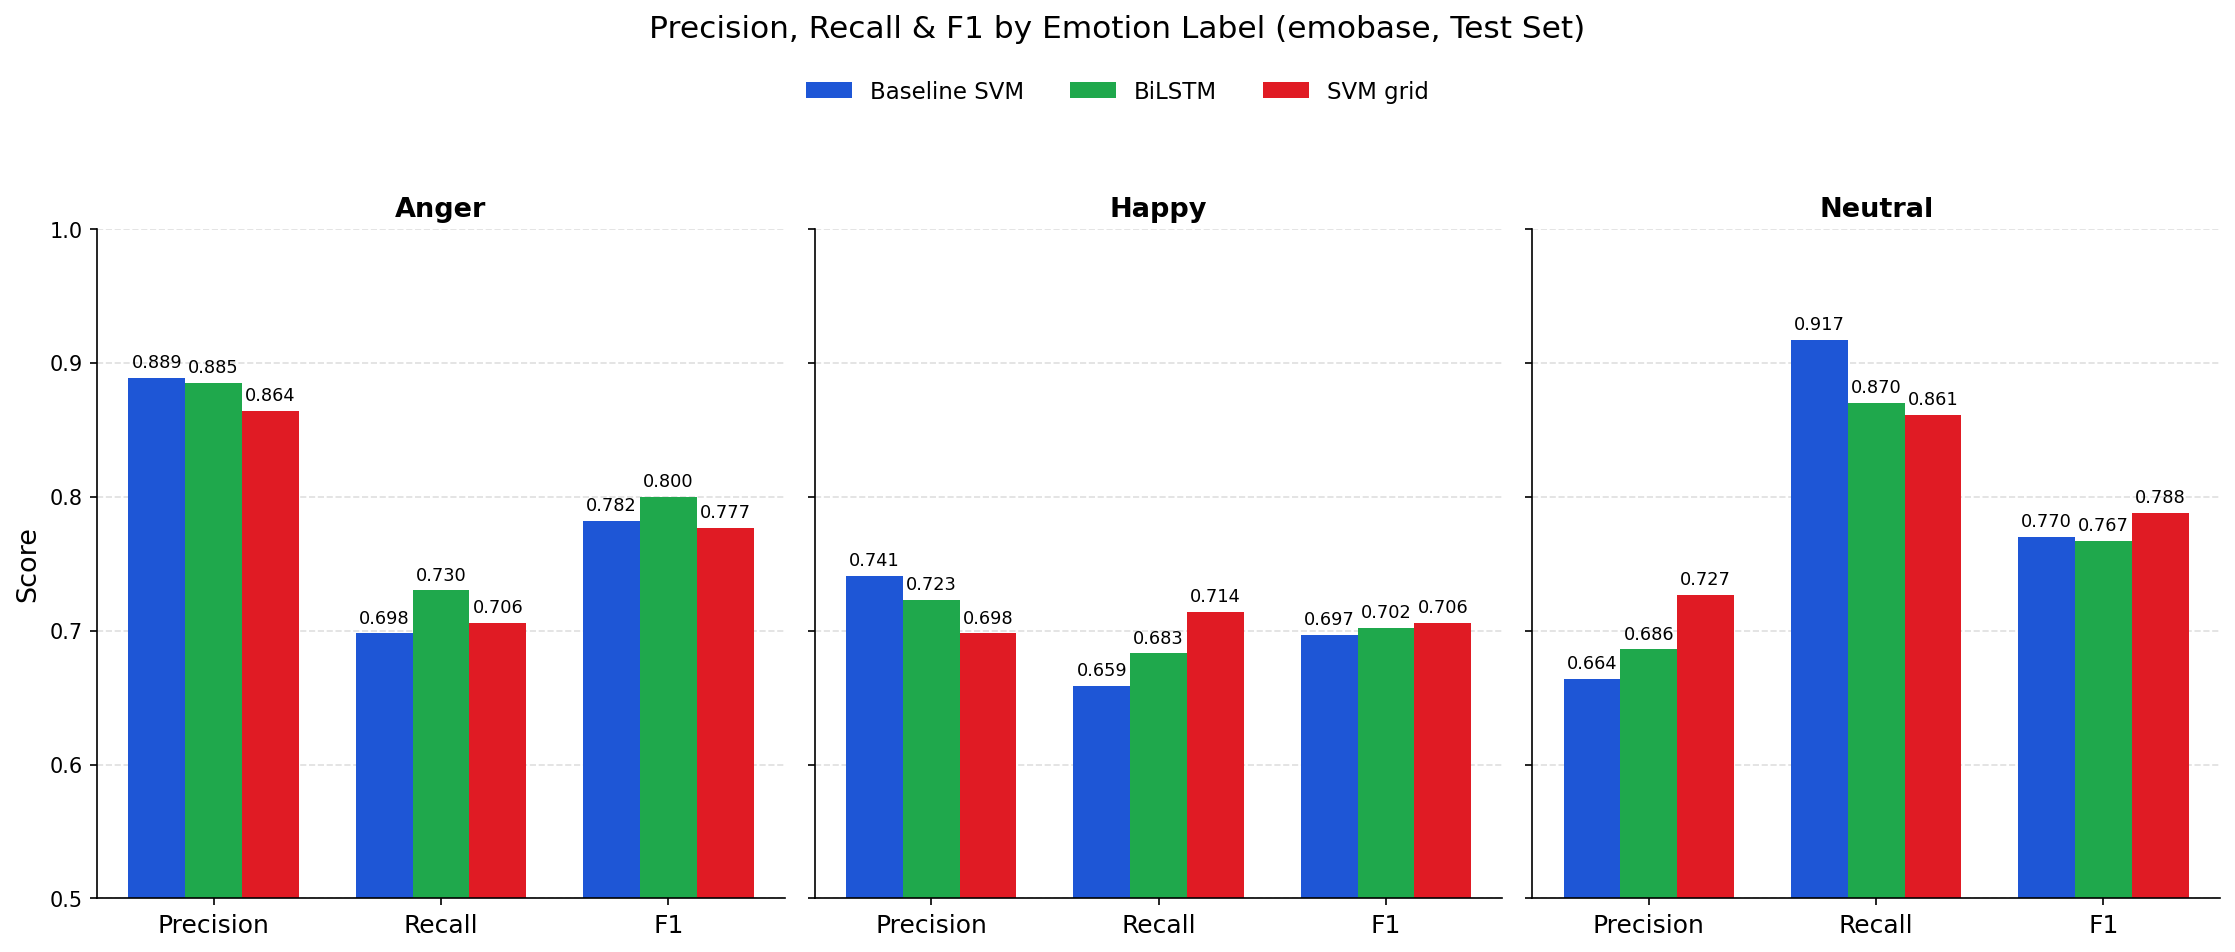

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

emotions = ["Anger", "Happy", "Neutral"]
metrics = ["Precision", "Recall", "F1"]

data = {
    "Baseline SVM": {"Anger": [0.889, 0.698, 0.782], "Happy": [0.741, 0.659, 0.697], "Neutral": [0.664, 0.917, 0.770]},
    "BiLSTM":       {"Anger": [0.885, 0.730, 0.800], "Happy": [0.723, 0.683, 0.702], "Neutral": [0.686, 0.870, 0.767]},
    "SVM grid":     {"Anger": [0.864, 0.706, 0.777], "Happy": [0.698, 0.714, 0.706], "Neutral": [0.727, 0.861, 0.788]},
}

colors = {
    "Baseline SVM": "#1E56D6",
    "BiLSTM":       "#1FA84C",
    "SVM grid":     "#E01B24",
}

models = list(data.keys())
x = np.arange(len(metrics))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(15, 6), dpi=150, sharey=True)

for idx, emo in enumerate(emotions):
    ax = axes[idx]
    for i, model in enumerate(models):
        offset = (i - (len(models) - 1) / 2) * width
        vals = data[model][emo]
        bars = ax.bar(x + offset, vals, width, label=model if idx == 0 else None,
                       color=colors[model], zorder=2)
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=12)
    ax.set_title(emo, fontsize=13, fontweight="bold")
    ax.set_ylim(0.5, 1.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if idx == 0:
        ax.set_ylabel("Score", fontsize=13)

fig.suptitle("Precision, Recall & F1 by Emotion Label (emobase, Test Set)", fontsize=15, y=1.05)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0),
           ncol=3, frameon=False, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("emobase_precision_recall_f1.png", bbox_inches="tight")